In [23]:
import os

os.environ["KAGGLE_API_TOKEN"] = "5eef1419bcc6b8bbfdefba56492fe3fa"

In [2]:
!pip install kaggle

In [15]:
!kaggle --version

Kaggle API 1.8.2


In [19]:
import json

with open(r"C:\Users\user\.kaggle\kaggle.json", "r") as f:
    data = json.load(f)

print(data.keys())
print(data["username"])
print(len(data["key"]))

dict_keys(['username', 'key'])
harimskaggle
32


In [24]:
!kaggle competitions list

Could not find kaggle.json. Make sure it's located in C:\Users\user\.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [18]:
!kaggle competitions download -c titanic

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


현업 실무 과정
1. 비즈니스 문제 정의 & 목표 설정 (NSM, ORK, KPI) (마케터, 기획자, 전략파트)
2. 데이터 기획자 (Data Achitecture) : 주로 PM 담당. 각 단계에 대한 이해도, 이슈사항 경험. 
3. 데이터 수집가 (crawling / api / research)
4. 데이터 저장 (RDBMS / NoSQL / MySQL / MongoDB)
5. 데이터 시각화 -1 > 로우 데이터 기반 전반적인 데이터 현황
6. 데이터 분석가 (EDA)
7. 데이터 시각화 -2 > 불필요한 데이터를 걷어버리고, 데이터 마이닝 된 상태에서 인사이트 도출 
8. 데이터 엔지니어 (Feature Engineering)
9. 데이터 엔지니어 (Modeling) > 적합한 알고리즘(머신러닝/딥러닝) 탐색 후 채택
10. 모델에게 입력할 매개변수 정의
11. 예측
12. 예측 결과에 대한 확률을 지속적으로 개선
13. 현업 적용 (마케터, 기획자, 전략파트 등)

In [9]:
import pandas as pd

train = pd.read_csv("titanic/train.csv")
test= pd.read_csv("titanic/test.csv")

In [11]:
train.head()

# PassengerId : 탑승한 승객 unique ID
# Survived : 생존 여부 (0 사망 / 1 생존)
# Pclass : 객실 등급 (1=1st / 2=2nd / 3=3rd)
# SibSp : 형제자매 | 배우자 동반 여부 (0 없음 / 1 이상 동승 인원)
# Parch : 부모 | 자녀와 동반 여부 (0 없음 / 1 이상 동승 인원)
# Ticket : 탑승시 티켓 번호 
# Fare : 탑승 요금 (객실 등급, 수하물 위탁 서비스) 
# Cabin : 짐칸 선실 번호
# Embarked : 정박지 (S=Southhampton / C=Cherbourg / Q=Queenstown) 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
test.head()

#train.csv와 다른 점 : Survived가 없음. 왜? train으로 학습하고 test로 확인

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [16]:
# 1) 데이터 규모 / 사이즈 
# 총 891명의 승객 정보를 활용해서 학습 시킬 것. 피처는 12개로서 각 피처 간의 상관관계를 분석

train.shape

(891, 12)

In [18]:
# 418명의 승객정보를 맞추는 미션, 생존 여부를 판단하는 컬럼 1개 부족. (survived)
test.shape

(418, 11)

In [19]:
# 2) 데이터 명세서 : 세부적인 컬럼별 데이터 타입 & 결측 여부
# 연령, 선실, 정박지에 결측치 발생. 전체 데이터에 날짜 타입 없음. 정수/실수/문자

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [20]:
# 연령, 선실 동일하게 결측치 발생. 요금은 결측지 있음. 정박지 결측지 없음. 
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [23]:
# 3) 구체적인 결측 컬럼 갯수
# 현재 결측치로 판단된 값들을 어떤 방식으로 대체할지 고민 필요 : 삭제 / 교체
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [22]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [25]:
# 4) 평균, 중앙(간), 사분위값 (1~3), 이상치(상/하한)
# 5 Number Summary
# 수치 데이터 중심으로 평균, 이상치 존재 여부 판단

train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# 지금까지의 데이터만 가지고는 어떤 데이터가 우리에게 꼭 필요한지 의사결정을 내리기에는 어려움 
# 1차 시각화 필요. 이를 통해 어떤 데이터가 우리에게 필요한지 검증. 

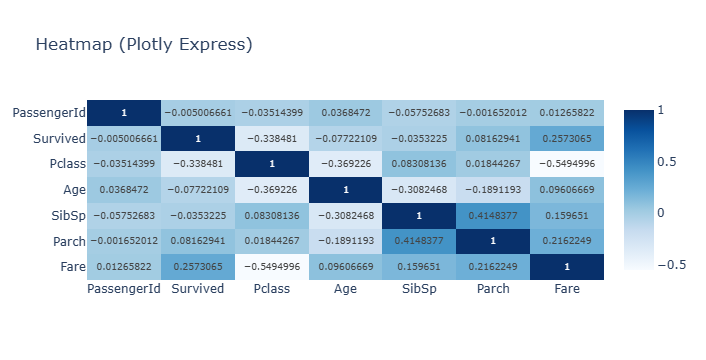

In [26]:
import plotly.express as px

# 상관관계 분석
corr_matrix = train.corr(numeric_only=True)

fig_px = px.imshow(
    corr_matrix,
    text_auto=True,
    aspect="auto",
    title="Heatmap (Plotly Express)",
    color_continuous_scale="Blues"
)

fig_px.show()

# 실제 생존 여부 판단을 위한 각 컬럼들의 상관관계 여부 대략 파악 : 승객 요금(선실위치)과 상관관계 있음
# 컬럼간 상관관계 여부 추가 파악 : 형제자매,배우자 탑승시 부모,자녀 탑승과 상관관계가 높다
# 만약 컬럼간 표면상의 상관관계가 눈에 띄는 단서가 없는 경우, 경험치, 도메인.
# 타이타닉을 탑승한 시기에 직업 귀천이 있었음. 이름 앞에 붙는 명칭을 활용해서 생존/사망 여부 상관관계 분석 필요
# 예를 들면, 성별도 현재로선 히트맵에 나타나지 않음. 